# 🧠 Class 8.3 — Perceptrons, Activation Functions & Forward Propagation
Machine Learning Techniques | Week 8

---

**Learning Goals:**
- Understand what activation functions do and why they are necessary
- Visualise ReLU, Sigmoid, and Tanh and know when to use each
- Implement forward propagation through a 2-layer neural network using only numpy
- Read and annotate tensor shapes at each layer

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
np.random.seed(42)

print('✅ Setup complete')

✅ Setup complete


---
## Part 1 — Activation Functions

An activation function is applied to the output of each neuron. Without it, stacking multiple layers is mathematically equivalent to a single linear transformation — you get no benefit from depth.

Activation functions introduce **non-linearity**, which is what allows neural networks to learn complex patterns.

### The three most important activation functions:

| Function | Formula | Range | When to use |
|---|---|---|---|
| **ReLU** | max(0, x) | [0, ∞) | Hidden layers (default choice) |
| **Sigmoid** | 1 / (1 + e^(-x)) | (0, 1) | Binary output layer |
| **Tanh** | (e^x - e^(-x)) / (e^x + e^(-x)) | (-1, 1) | Hidden layers (older models) |
| **Softmax** | e^xᵢ / Σe^xⱼ | (0,1), sums to 1 | Multi-class output layer |

In [2]:
# Define the activation functions using numpy
# ReLU: max(0, x) — any negative value becomes 0, positives unchanged
def relu(x):
    return np.maximum(0, x)

# Sigmoid: 1 / (1 + e^(-x)) — squashes everything into (0, 1)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Tanh: (e^x - e^(-x)) / (e^x + e^(-x)) — squashes everything into (-1, 1)
def tanh(x):
    return np.tanh(x)

# Test your functions
test_vals = np.array([-3, -1, 0, 1, 3])
print('Test values:', test_vals)
print('ReLU:   ', relu(test_vals))
print('Sigmoid:', np.round(sigmoid(test_vals), 3))
print('Tanh:   ', np.round(tanh(test_vals), 3))
print()
print('Expected ReLU: [0, 0, 0, 1, 3]')
print('Expected Sigmoid (approx): [0.047, 0.269, 0.5, 0.731, 0.953]')


Test values: [-3 -1  0  1  3]
ReLU:    [0 0 0 1 3]
Sigmoid: [0.047 0.269 0.5   0.731 0.953]
Tanh:    [-0.995 -0.762  0.     0.762  0.995]

Expected ReLU: [0, 0, 0, 1, 3]
Expected Sigmoid (approx): [0.047, 0.269, 0.5, 0.731, 0.953]


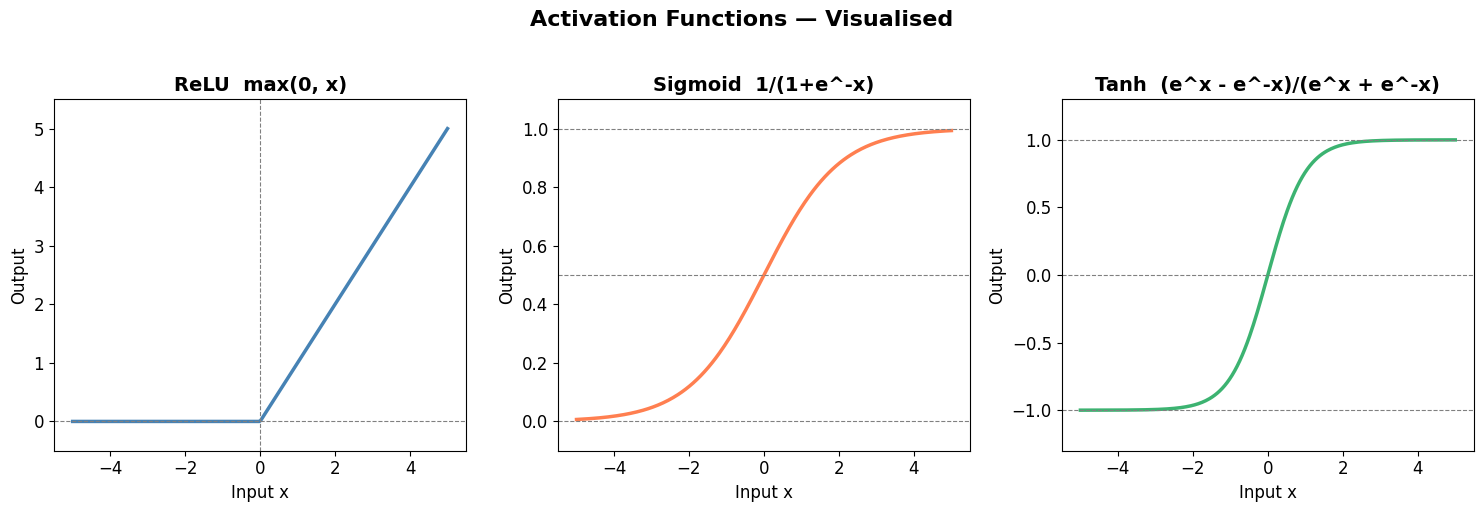

QUESTIONS:
1. What is the output of ReLU for any negative input?
   Answer: 0

2. What is the output of Sigmoid when x=0?
   Answer: 0.5

3. What is the range of Tanh? Why might this be useful in a hidden layer?
   Answer: (-1, 1). It is zero-centred, so gradients flow more evenly
           than with sigmoid, helping deeper networks train faster.


In [3]:
# Visualise all three activation functions on the same figure
x = np.linspace(-5, 5, 300)  # 300 evenly spaced values from -5 to 5

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Plot 1: ReLU ────────────────────────────────────────────────────────
axes[0].plot(x, relu(x), color='steelblue', linewidth=2.5)
axes[0].set_title('ReLU  max(0, x)', fontsize=14, fontweight='bold')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Input x'); axes[0].set_ylabel('Output')
axes[0].set_ylim(-0.5, 5.5)


# ── Plot 2: Sigmoid ──────────────────────────────────────────────────────
axes[1].plot(x, sigmoid(x), color='coral', linewidth=2.5)
axes[1].set_title('Sigmoid  1/(1+e^-x)', fontsize=14, fontweight='bold')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Input x'); axes[1].set_ylabel('Output')
axes[1].set_ylim(-0.1, 1.1)


# ── Plot 3: Tanh ─────────────────────────────────────────────────────────
axes[2].plot(x, tanh(x), color='mediumseagreen', linewidth=2.5)
axes[2].set_title('Tanh  (e^x - e^-x)/(e^x + e^-x)', fontsize=14, fontweight='bold')
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[2].axhline(-1, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('Input x'); axes[2].set_ylabel('Output')
axes[2].set_ylim(-1.3, 1.3)


plt.suptitle('Activation Functions — Visualised', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Answer these questions after looking at the plots:
print('QUESTIONS:')
print('1. What is the output of ReLU for any negative input?')
print('   Answer: 0')
print()
print('2. What is the output of Sigmoid when x=0?')
print('   Answer: 0.5')
print()
print('3. What is the range of Tanh? Why might this be useful in a hidden layer?')
print('   Answer: (-1, 1). It is zero-centred, so gradients flow more evenly')
print('           than with sigmoid, helping deeper networks train faster.')


---
## Part 2 — Forward Propagation from Scratch

Forward propagation is the process of computing predictions: pass inputs through each layer, apply weights and biases, apply activation function, repeat.

**The math for one layer:**
```
Z = X @ W + b      # linear transformation (@ = matrix multiply)
A = activation(Z)  # non-linear activation
```

**Shape tracking is critical:**
- X has shape (batch_size × n_features)
- W has shape (n_features × n_neurons_this_layer)
- b has shape (1 × n_neurons_this_layer) — broadcasts across batch
- Z = X @ W + b has shape (batch_size × n_neurons_this_layer) ✓

We will implement a 2-layer network:
```
Input (4) → Hidden Layer (3 neurons, ReLU) → Output (1 neuron, Sigmoid)
```

In [4]:
# We will use our Titanic features as input
# For this exercise: Age, Fare, Sex (encoded), Pclass
# Let's create a tiny 5-sample batch to trace shapes easily

# Input: 5 passengers, 4 features each
X_batch = np.array([
    [22.0, 7.25,  1, 3],  # male, 3rd class
    [38.0, 71.28, 0, 1],  # female, 1st class
    [26.0, 7.92,  0, 3],  # female, 3rd class
    [35.0, 53.10, 0, 1],  # female, 1st class
    [35.0, 8.05,  1, 3],  # male, 3rd class
])

# True labels (did they survive?)
y_true = np.array([0, 1, 1, 1, 0])  # 0=died, 1=survived

print('Input batch shape:', X_batch.shape)
print('Expected: (5, 4) = 5 samples, 4 features')
print()
print('Input matrix:')
print(X_batch)

Input batch shape: (5, 4)
Expected: (5, 4) = 5 samples, 4 features

Input matrix:
[[22.    7.25  1.    3.  ]
 [38.   71.28  0.    1.  ]
 [26.    7.92  0.    3.  ]
 [35.   53.1   0.    1.  ]
 [35.    8.05  1.    3.  ]]


In [5]:
# Initialize weights and biases randomly
# We use small random values (not zeros — all-zero weights don't learn)
np.random.seed(42)

n_input   = 4   # 4 features
n_hidden  = 3   # 3 neurons in hidden layer
n_output  = 1   # 1 output (binary: survived or not)

# Layer 1 weights: shape must be (n_input, n_hidden) = (4, 3)
W1 = np.random.randn(n_input, n_hidden) * 0.1
b1 = np.zeros((1, n_hidden))            # shape: (1, 3)

# Layer 2 weights: shape must be (n_hidden, n_output) = (3, 1)
W2 = np.random.randn(n_hidden, n_output) * 0.1
b2 = np.zeros((1, n_output))            # shape: (1, 1)

print('Weight and bias shapes:')
print(f'W1: {W1.shape}  (should be {n_input} × {n_hidden})')
print(f'b1: {b1.shape}  (should be 1 × {n_hidden})')
print(f'W2: {W2.shape}  (should be {n_hidden} × {n_output})')
print(f'b2: {b2.shape}  (should be 1 × {n_output})')

Weight and bias shapes:
W1: (4, 3)  (should be 4 × 3)
b1: (1, 3)  (should be 1 × 3)
W2: (3, 1)  (should be 3 × 1)
b2: (1, 1)  (should be 1 × 1)


In [6]:
# ── FORWARD PROPAGATION ───────────────────────────────────────────────────
# Layer 1: Linear transformation then ReLU activation

# Step 1: Z1 = X_batch @ W1 + b1
# The @ symbol = matrix multiplication
# Shape: (5, 4) @ (4, 3) + (1, 3) = (5, 3)
Z1 = X_batch @ W1 + b1

print(f'Z1 shape: {Z1.shape}  (should be (5, 3) = 5 samples × 3 hidden neurons)')
print('Z1 (pre-activation values):')
print(Z1.round(4))


Z1 shape: (5, 3)  (should be (5, 3) = 5 samples × 3 hidden neurons)
Z1 (pre-activation values):
[[ 2.5177 -0.5362  1.0685]
 [12.7979 -2.2408  0.7457]
 [ 2.6605 -0.684   1.3588]
 [ 9.88   -1.7736  0.9771]
 [ 3.2852 -0.7347  1.8918]]


In [7]:
# Step 2: A1 = relu(Z1)
# Apply ReLU activation — any negative Z1 value becomes 0
A1 = relu(Z1)

print(f'A1 shape: {A1.shape}  (same as Z1 — activation does not change shape)')
print('A1 (after ReLU — no negatives):')
print(A1.round(4))
print()
print('Check: are all values >= 0? (ReLU kills negatives)')
print(f'Min value in A1: {A1.min():.4f}  (should be >= 0)')


A1 shape: (5, 3)  (same as Z1 — activation does not change shape)
A1 (after ReLU — no negatives):
[[ 2.5177  0.      1.0685]
 [12.7979  0.      0.7457]
 [ 2.6605  0.      1.3588]
 [ 9.88    0.      0.9771]
 [ 3.2852  0.      1.8918]]

Check: are all values >= 0? (ReLU kills negatives)
Min value in A1: 0.0000  (should be >= 0)


In [8]:
# Layer 2: Linear transformation then Sigmoid activation (output layer)

# Step 3: Z2 = A1 @ W2 + b2
# Shape: (5, 3) @ (3, 1) + (1, 1) = (5, 1)
Z2 = A1 @ W2 + b2

print(f'Z2 shape: {Z2.shape}  (should be (5, 1))')
print('Z2 (pre-activation values for output layer):')
print(Z2.round(4))


Z2 shape: (5, 1)  (should be (5, 1))
Z2 (pre-activation values for output layer):
[[-0.1234]
 [ 0.181 ]
 [-0.17  ]
 [ 0.0705]
 [-0.2468]]


In [9]:
# Step 4: A2 = sigmoid(Z2)  → final predictions (probabilities 0 to 1)
A2 = sigmoid(Z2)

print(f'A2 shape: {A2.shape}  (should be (5, 1))')
print('A2 (predicted survival PROBABILITIES):')
print(A2.round(4))
print()
print('Check: all values between 0 and 1? (Sigmoid guarantees this)')
print(f'Min: {A2.min():.4f}, Max: {A2.max():.4f}')


A2 shape: (5, 1)  (should be (5, 1))
A2 (predicted survival PROBABILITIES):
[[0.4692]
 [0.5451]
 [0.4576]
 [0.5176]
 [0.4386]]

Check: all values between 0 and 1? (Sigmoid guarantees this)
Min: 0.4386, Max: 0.5451


In [10]:
# Convert probabilities to binary predictions (threshold = 0.5)
# If probability >= 0.5 → predict 1 (survived)
# If probability <  0.5 → predict 0 (did not survive)

predictions = (A2 >= 0.5).astype(int).flatten()

print('Summary of forward pass:')
print(f'{"Sample":<8} {"Predicted Prob":<18} {"Predicted":<12} {"True Label":<12} {"Correct?"}')
print('-' * 60)
for i in range(len(y_true)):
    correct = '✓' if predictions[i] == y_true[i] else '✗'
    print(f'{i+1:<8} {A2[i,0]:.4f}            {predictions[i]:<12} {y_true[i]:<12} {correct}')

accuracy = (predictions == y_true).mean()
print(f'\nAccuracy on this 5-sample batch: {accuracy:.0%}')
print('(Random weights → poor accuracy is expected. Training will fix this.)')

Summary of forward pass:
Sample   Predicted Prob     Predicted    True Label   Correct?
------------------------------------------------------------
1        0.4692            0            0            ✓
2        0.5451            1            1            ✓
3        0.4576            0            1            ✗
4        0.5176            1            1            ✓
5        0.4386            0            0            ✓

Accuracy on this 5-sample batch: 80%
(Random weights → poor accuracy is expected. Training will fix this.)


---
## Part 3 — Shape Annotation Exercise

Understanding tensor shapes is one of the most critical skills when building neural networks. Dimension errors are the #1 bug when starting out.

Fill in the missing shapes below:

In [11]:
# Shape annotation exercise — fill in the blanks

print('=== SHAPE ANNOTATION EXERCISE ===')
print()
print('Network: Input(4) → Hidden(8, ReLU) → Hidden(4, ReLU) → Output(1, Sigmoid)')
print('Batch size: 32 samples')
print()

# Fill in the shapes
answers = {
    'X (input)':          '(32, 4)',
    'W1 (layer 1)':       '(4, 8)',
    'b1 (layer 1)':       '(1, 8)',
    'Z1 = X @ W1 + b1':  '(32, 8)',
    'A1 = ReLU(Z1)':      '(32, 8)',
    'W2 (layer 2)':       '(8, 4)',
    'b2 (layer 2)':       '(1, 4)',
    'Z2 = A1 @ W2 + b2': '(32, 4)',
    'A2 = ReLU(Z2)':      '(32, 4)',
    'W3 (layer 3)':       '(4, 1)',
    'b3 (layer 3)':       '(1, 1)',
    'Z3 = A2 @ W3 + b3': '(32, 1)',
    'A3 = Sigmoid(Z3)':   '(32, 1)',  # one probability per sample
}

for name, shape in answers.items():
    print(f'  {name:<28} shape = {shape}')


=== SHAPE ANNOTATION EXERCISE ===

Network: Input(4) → Hidden(8, ReLU) → Hidden(4, ReLU) → Output(1, Sigmoid)
Batch size: 32 samples

  X (input)                    shape = (32, 4)
  W1 (layer 1)                 shape = (4, 8)
  b1 (layer 1)                 shape = (1, 8)
  Z1 = X @ W1 + b1             shape = (32, 8)
  A1 = ReLU(Z1)                shape = (32, 8)
  W2 (layer 2)                 shape = (8, 4)
  b2 (layer 2)                 shape = (1, 4)
  Z2 = A1 @ W2 + b2            shape = (32, 4)
  A2 = ReLU(Z2)                shape = (32, 4)
  W3 (layer 3)                 shape = (4, 1)
  b3 (layer 3)                 shape = (1, 1)
  Z3 = A2 @ W3 + b3            shape = (32, 1)
  A3 = Sigmoid(Z3)             shape = (32, 1)


In [12]:
# Verify your answers by running actual numpy operations
np.random.seed(0)
batch = 32

X_ex  = np.random.randn(batch, 4)
W1_ex = np.random.randn(4, 8) * 0.1
b1_ex = np.zeros((1, 8))
W2_ex = np.random.randn(8, 4) * 0.1
b2_ex = np.zeros((1, 4))
W3_ex = np.random.randn(4, 1) * 0.1
b3_ex = np.zeros((1, 1))

Z1_ex = X_ex @ W1_ex + b1_ex
A1_ex = relu(Z1_ex)
Z2_ex = A1_ex @ W2_ex + b2_ex
A2_ex = relu(Z2_ex)
Z3_ex = A2_ex @ W3_ex + b3_ex
A3_ex = sigmoid(Z3_ex)

print('Actual shapes — check against your answers:')
for name, arr in [('X', X_ex), ('W1', W1_ex), ('b1', b1_ex),
                   ('Z1', Z1_ex), ('A1', A1_ex),
                   ('W2', W2_ex), ('b2', b2_ex),
                   ('Z2', Z2_ex), ('A2', A2_ex),
                   ('W3', W3_ex), ('b3', b3_ex),
                   ('Z3', Z3_ex), ('A3', A3_ex)]:
    print(f'  {name:<5} shape = {arr.shape}')

Actual shapes — check against your answers:
  X     shape = (32, 4)
  W1    shape = (4, 8)
  b1    shape = (1, 8)
  Z1    shape = (32, 8)
  A1    shape = (32, 8)
  W2    shape = (8, 4)
  b2    shape = (1, 4)
  Z2    shape = (32, 4)
  A2    shape = (32, 4)
  W3    shape = (4, 1)
  b3    shape = (1, 1)
  Z3    shape = (32, 1)
  A3    shape = (32, 1)


---
## Part 4 — What Changes When We Use Different Activations?

Let's see how using Sigmoid vs ReLU in the hidden layer changes the activations for the same input.

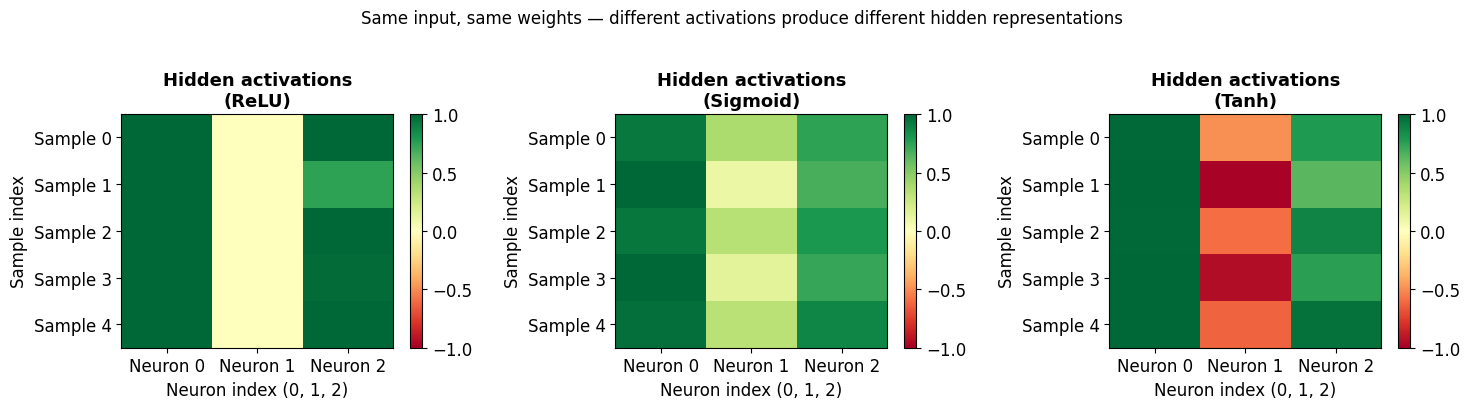

After looking at the heatmaps:
1. Which activation has the most zeros (dead neurons)?
   Answer: ReLU — every negative pre-activation becomes exactly 0.

2. Which activation keeps negative values?
   Answer: Tanh — it outputs values in (-1, 1).

3. Which activation is most "squashed" into a narrow range?
   Answer: Sigmoid — its output is bounded to (0, 1).


In [13]:
# Same weights, same input — but different hidden activation
# Compare A1 when using ReLU vs Sigmoid in the hidden layer

Z1_same = X_batch @ W1 + b1   # same linear step

A1_relu    = relu(Z1_same)
A1_sigmoid = sigmoid(Z1_same)
A1_tanh    = tanh(Z1_same)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, A1, name, color in zip(
    axes,
    [A1_relu, A1_sigmoid, A1_tanh],
    ['ReLU', 'Sigmoid', 'Tanh'],
    ['steelblue', 'coral', 'mediumseagreen']
):
    im = ax.imshow(A1, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
    ax.set_title(f'Hidden activations\n({name})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Neuron index (0, 1, 2)')
    ax.set_ylabel('Sample index')
    ax.set_yticks(range(5))
    ax.set_yticklabels([f'Sample {i}' for i in range(5)])
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Neuron 0', 'Neuron 1', 'Neuron 2'])
    plt.colorbar(im, ax=ax)

plt.suptitle('Same input, same weights — different activations produce different hidden representations',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('After looking at the heatmaps:')
print('1. Which activation has the most zeros (dead neurons)?')
print('   Answer: ReLU — every negative pre-activation becomes exactly 0.')
print()
print('2. Which activation keeps negative values?')
print('   Answer: Tanh — it outputs values in (-1, 1).')
print()
print('3. Which activation is most "squashed" into a narrow range?')
print('   Answer: Sigmoid — its output is bounded to (0, 1).')


---
## ✅ Notebook Complete!

**What you built today — entirely from scratch with numpy:**
- Implemented ReLU, Sigmoid, and Tanh activation functions
- Performed a complete 2-layer forward pass: Input → Z1 → A1 → Z2 → A2
- Tracked tensor shapes at every step
- Saw how different activations produce different hidden representations

**Key insight:** The weights we used were random — the network made bad predictions. In 8.4 we will learn **backpropagation** — how the network measures how wrong it is and adjusts the weights to do better.